# Modelo convolucional 1D

Entrenamiento del modelo convolucional descrito en la memoria (apartado *Modelo convolucional 1D*).

Planteamiento de superresolución:

1. El espectro de Gaia se interpola linealmente sobre la malla de longitudes de onda de SDSS, de modo que entrada y salida quedan alineadas punto a punto.
2. Una red convolucional residual aprende la **corrección** que hay que aplicar sobre el espectro interpolado (conexión residual global), en lugar de generar el espectro completo desde cero.
3. Cada par de espectros se normaliza con la mediana del flujo de Gaia, por lo que la normalización puede deshacerse usando solo la entrada (aplicable a observaciones nuevas sin conocer el espectro de SDSS).

In [1]:
import numpy as np
from pathlib import Path

# Ruta relativa al notebook para que funcione en cualquier equipo
data_dir = Path("../data/splits")
candidates = [
    data_dir / "processed_data_no_duplicates.npz",
    data_dir / "processed_data.npz",
]
processed_path = next(path for path in candidates if path.exists())
print("Usando:", processed_path)

data = np.load(processed_path)
print(data.files)

Usando: ..\data\splits\processed_data.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'gaia_wavelength', 'sdss_wavelength']


In [2]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de Gaia y SDSS
X_id_test = data["X_id_test"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

print("Gaia:", X_train.shape, "| SDSS:", y_train.shape)

Gaia: (31256, 201) | SDSS: (31256, 2666)


Normalizamos cada par de espectros con la mediana del flujo de Gaia. Como ambos flujos están en las mismas unidades y los pares con escalas incoherentes ya se descartaron en el preprocesado, el espectro de SDSS normalizado queda en una escala cercana a 1.

In [3]:
# Escala por espectro: mediana del flujo de Gaia
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

X_train_norm = X_train / X_scale_train
X_val_norm = X_val / X_scale_val
X_test_norm = X_test / X_scale_test

# El objetivo se normaliza con la misma escala que su entrada
y_train_norm = y_train / X_scale_train
y_val_norm = y_val / X_scale_val
y_test_norm = y_test / X_scale_test

Interpolamos el espectro de Gaia sobre la malla de longitudes de onda de SDSS. Esta versión interpolada es la entrada de la red y también la base sobre la que se aplica la corrección residual.

In [4]:
def interpolate_to_sdss_grid(spectra):
    return np.stack([
        np.interp(sdss_wavelength, gaia_wavelength, spectrum)
        for spectrum in spectra
    ])

X_train_interp = interpolate_to_sdss_grid(X_train_norm)
X_val_interp = interpolate_to_sdss_grid(X_val_norm)
X_test_interp = interpolate_to_sdss_grid(X_test_norm)

print(X_train_interp.shape, "->", y_train_norm.shape)

(31256, 2666) -> (31256, 2666)


Arquitectura: capa convolucional inicial (64 filtros, núcleo 9), cuatro bloques residuales (dos convoluciones de 64 filtros con núcleo 7 y activación ELU, más un atajo) y una convolución final de un filtro que genera la corrección. La conexión residual global suma la entrada interpolada a dicha corrección.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_sdss = y_train.shape[1]


def residual_block(x, filters=64, kernel_size=7):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="elu")(x)
    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = layers.Add()([x, shortcut])
    return layers.Activation("elu")(x)


inputs = layers.Input(shape=(n_sdss, 1))

x = layers.Conv1D(64, 9, padding="same", activation="elu")(inputs)

for _ in range(4):
    x = residual_block(x)

correction = layers.Conv1D(1, 5, padding="same")(x)

# Conexión residual global: salida = entrada interpolada + corrección
outputs = layers.Add()([inputs, correction])
outputs = layers.Reshape((n_sdss,))(outputs)

model_cnn = models.Model(inputs, outputs, name="cnn_residual_1d")

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

Model: "cnn_residual_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2666, 64)  │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2666, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2666, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2666, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2666, 64)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2666, 64)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2666, 1)   │        321 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 2666, 1)   │          0 │ input_layer[0][0… │
│                     │                   │            │ conv1d_9[0][0]  

 Total params: 230,849 (901.75 KB)

 Trainable params: 230,849 (901.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model_cnn.fit(
    X_train_interp[..., None],
    y_train_norm,
    validation_data=(X_val_interp[..., None], y_val_norm),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 829s 2s/step - loss: 0.0198 - mae: 0.1330 - mse: 0.0430 - val_loss: 0.0172 - val_mae: 0.1220 - val_mse: 0.0403 - learning_rate: 1.0000e-04
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 813s 2s/step - loss: 0.0163 - mae: 0.1191 - mse: 0.0359 - val_loss: 0.0162 - val_mae: 0.1170 - val_mse: 0.0384 - learning_rate: 1.0000e-04
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 789s 2s/step - loss: 0.0158 - mae: 0.1166 - mse: 0.0349 - val_loss: 0.0161 - val_mae: 0.1170 - val_mse: 0.0381 - learning_rate: 1.0000e-04
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 776s 2s/step - loss: 0.0156 - mae: 0.1154 - mse: 0.0345 - val_loss: 0.0161 - val_mae: 0.1170 - val_mse: 0.0382 - learning_rate: 1.0000e-04
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0156 - mae: 0.1153 - mse: 0.0345
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
489/489 ━━━━━━━━━━━━━━━━━━━━ 818s 2s/step - loss: 0.0156 - mae: 0.1153 - mse: 0.0345 - val_loss: 0.0161 - val_mae:

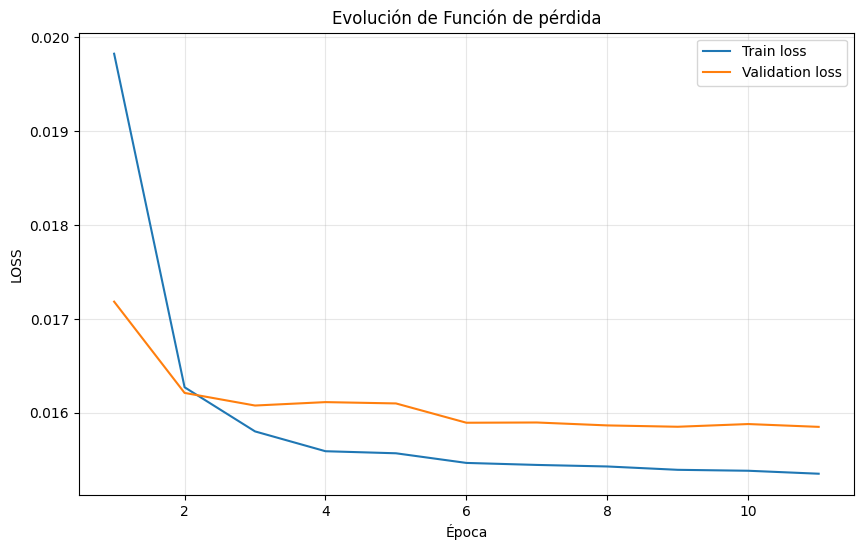

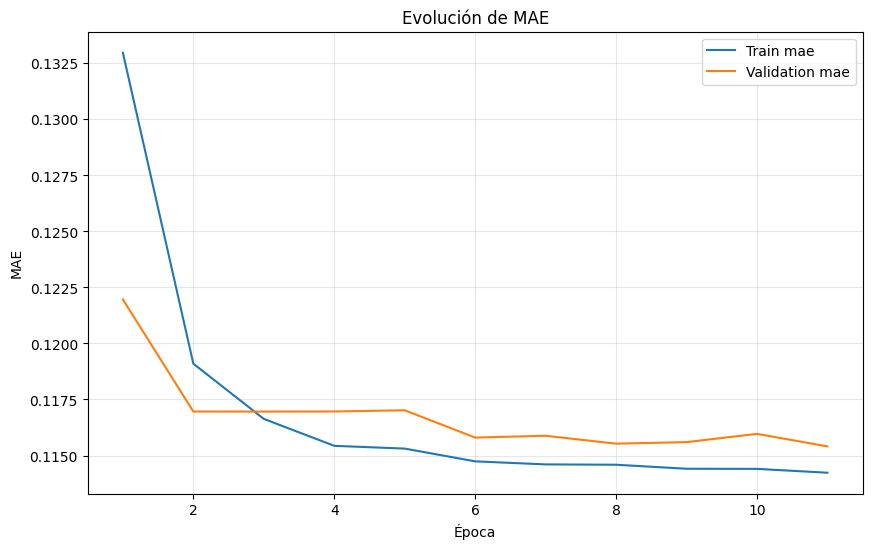

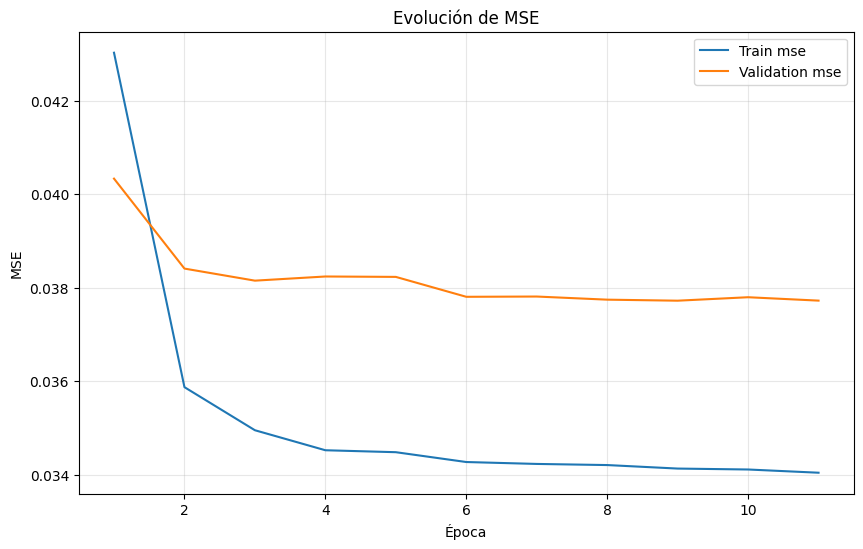

In [7]:
import matplotlib.pyplot as plt

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, history_dict[metric], label=f"Train {metric}")
    plt.plot(epochs, history_dict[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [8]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_interp[..., None],
    y_test_norm,
    verbose=1
)

306/306 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step - loss: 0.0153 - mae: 0.1137 - mse: 0.0352


In [9]:
y_pred_norm = model_cnn.predict(X_test_interp[..., None])

# Deshacemos la normalización solo con la escala de la entrada de Gaia
y_pred = y_pred_norm * X_scale_test

306/306 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step


In [ ]:
# Mismos objetos usados en las comparativas de la memoria
for i in [123, 191]:
    plt.figure(figsize=(10, 5))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Gaia source_id: {X_id_test[i]} | SDSS obj_id: {y_id_test[i]}")
    plt.legend()
    plt.show()

In [ ]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

mae_per_object = np.mean(np.abs(y_test - y_pred), axis=1)
mse_per_object = np.mean((y_test - y_pred) ** 2, axis=1)

worst_idx = np.argsort(mse_per_object)[-10:]

for i in worst_idx:
    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Peor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

In [ ]:
best_idx = np.argsort(mse_per_object)[:10]

for i in best_idx:
    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Mejor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

In [ ]:
# Guardamos el modelo entrenado para su evaluación y puesta en servicio
model_cnn.save("model-cnn.keras")